In [5]:
# this code is for forming simiulation object.

# basic imports
import numpy as np
import matplotlib.pylab as plt

# Tidy3D imports
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver


# materials
eff_inf = 100
n_sio2 = 1.444  # silicon oxide refractive index at 1550 nm
air = td.Medium(permittivity=1)
ln_no_coeffs = [(2.6734, 0.01764), (1.2290, 0.05914), (12.614, 474.60)]
ln_ne_coeffs = [(2.9804, 0.02047),  (0.5981, 0.0666),  (8.9543, 416.08)]
sio2_coeffs = [(0.6961663, 0.0684),  (0.40794, 0.11624),  (0.8974794, 9.89616)]



ln_no= td.Sellmeier(coeffs=ln_no_coeffs)
ln_ne= td.Sellmeier(coeffs=ln_ne_coeffs)
sio2= td.Sellmeier(coeffs=sio2_coeffs)
ln = td.AnisotropicMedium(xx=ln_no, yy=ln_ne, zz=ln_no)
## source
wavelength0 = 1.55
freq0 = td.C_0 / wavelength0
fwidth = freq0 / 40.0
run_time = 5.0e-12
wavelength_min = td.C_0 / (freq0 + fwidth)


# 파라미터 설정
sidewall_angle=(90-60)*np.pi/180
Hc=0.33
Hs=(0.6-Hc)

      # 전체 길이
mnum=150
w_wg= 2.2
l=2
size_x=2*2+l
size_y=1.55*1.2+w_wg*2




# boundary conditions - Bloch boundaries are used to emulate an infinitely long grating
boundary_spec = td.BoundarySpec(
    # x=td.Boundary.bloch(bloch_vec=num_periods/2),
    x=td.Boundary.pml(),
    y=td.Boundary.pml(),
    z=td.Boundary.pml(),
)




# create monitors
monitor_xy = td.FieldMonitor(
    center=[l/2, 0, 0],
    size=[l, 2 * wavelength0 + w_wg , 0],
    freqs=[freq0],
    name="fields_xy",
)

def structure_set(Hc,Hs,w_wg,sidewall_angle):

    # 윗부분과 아랫부분의 좌표를 결합하여 다각형 형태의 꼭짓점 정의
    vertices =[(eff_inf,-w_wg/2),(-eff_inf,-w_wg/2),(-eff_inf,w_wg/2),(0,w_wg/2)]
    LN_grating = td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"), medium=ln
    )
    # ln slab
    ln_substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-eff_inf, -eff_inf, -Hc/2-Hs),
            rmax=(eff_inf, eff_inf, -Hc/2),
        ),
        medium=ln,
    )


    # SiO2 BOX layer.
    sio2_substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-eff_inf, -eff_inf, -eff_inf),
            rmax=(eff_inf, eff_inf, -Hc/2-Hs),
        ),
        medium=sio2,
    )

    # list of all structures
    structures = (
        [LN_grating,ln_substrate,sio2_substrate]
    )
    return structures



# list of all monitors
monitors = [monitor_xy]



def sim_set(wavelength,Hc,Hs,w_wg,sidewall_angle):
    freq0 = td.C_0 / wavelength
    structures=structure_set(Hc,Hs,w_wg,sidewall_angle)
    # grid specification
    grid_spec = td.GridSpec.auto(min_steps_per_wvl=20)
    grid_spec_VIS = td.GridSpec.auto(min_steps_per_wvl=50)
    # mode source for waveguide 
    source1_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)
    mode_src1 = td.ModeSource(
        center=[0, 0, 0],
        size=[0, w_wg * 2, 3],
        mode_index=0,
        direction="+",
        source_time=source1_time,
        mode_spec=td.ModeSpec(),
    )
    # list of all sources
    sources = [mode_src1]
    # create the simulation
    sim = td.Simulation(

        center=(l/2, 0, 0),
        size=(size_x, size_y, Hc+Hs+4),
        grid_spec=grid_spec,
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        symmetry=(0, 0, 0),
    )

    sim2 = td.Simulation(

        center=(l/2, 0, 0),
        size=(size_x, size_y, Hc+Hs+4),
        grid_spec=grid_spec_VIS,
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        symmetry=(0, 0, 0),
    )

    return sim,sim2




### we are interested in QPM from 1550 nm to 775 nm
wavelength=1.55
Hnum=4
Wnum=4
thickness_set=np.linspace(0.4,0.7,Hnum)
width_set=np.linspace(2,3,Wnum)
Poling_set=np.zeros((Hnum,Wnum))
Hc=0.25 #etching depth
sidewall_angle=(90-60)*np.pi/180
for i, Hln in enumerate(thickness_set):
    Hs=Hln-Hc
    for j, width in enumerate(width_set):
        
        [sim,sim2]=sim_set(wavelength,Hc,Hs,w_wg=width,sidewall_angle=sidewall_angle)
        freq = td.C_0 / wavelength
        freq_vis = 2*td.C_0 / wavelength
        # Modal source plane
        source_plane1 = td.Box(center=[0, 0, 0], size=[0, 3, 2])

        mode_spec = td.ModeSpec(
            num_modes=5,
            target_neff=2.2,
        )
        # NB: negative radius since the plane position is at y=-radius
        ms1 = ModeSolver(simulation=sim, plane=source_plane1, freqs=freq, mode_spec=mode_spec)
        modes_IR = ms1.solve()
        ms2 = ModeSolver(simulation=sim2, plane=source_plane1, freqs=freq_vis, mode_spec=mode_spec)
        modes_VIS = ms2.solve()
        index_set_IR=modes_IR.pol_fraction.te.squeeze().values # convert into numpy array
        index_TE00_IR = np.argmax(index_set_IR> 0.5)
        index_set_VIS=modes_VIS.pol_fraction.te.squeeze().values # convert into numpy array
        index_TE00_VIS = np.argmax(index_set_VIS> 0.5)

        n1 = modes_IR.n_eff.values.squeeze()[index_TE00_IR ]
        n2 = modes_VIS.n_eff.values.squeeze()[index_TE00_VIS]
        Poling_set[i,j]=wavelength / (2 * (n1 - n2))





18:36:25 KST WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 4 does not    
             decay at the plane boundaries.                                     

18:36:27 KST WARNING: Mode field at frequency index 0, mode index 0 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

...

18:36:53 KST WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 4 does not    
             decay at the plane boundaries.                                     

18:36:55 KST WARNING: Mode field at frequency index 0, mode index 0 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

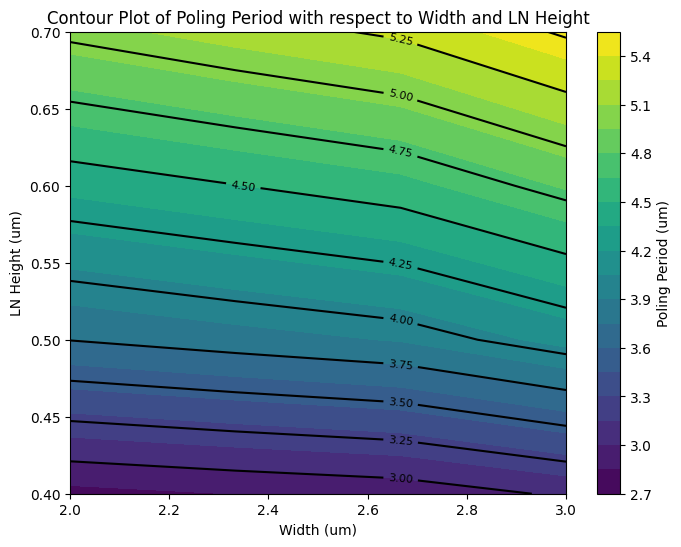

In [7]:


# Contour plot 그리기
fig, ax = plt.subplots(figsize=(8, 6))
# Contour plot 그리기 (채워진 등고선)
contour = ax.contourf(width_set, thickness_set, np.abs(Poling_set), cmap='viridis', levels=20)
# Contour 선 그리기 (선으로 표현된 등고선)
contour_lines = ax.contour(width_set, thickness_set, np.abs(Poling_set), colors='black', levels=10)

# 색상바 추가
cbar = fig.colorbar(contour)
cbar.set_label('Poling Period (um)')  # 색상바 레이블 설정

# 그래프 레이블 및 제목 설정
ax.set_xlabel('Width (um)')
ax.set_ylabel('LN Height (um)')
ax.set_title('Contour Plot of Poling Period with respect to Width and LN Height')

# Contour 레이블 추가
ax.clabel(contour_lines, inline=True, fontsize=8, colors='black')

# 그래프 보여주기
plt.show()


3


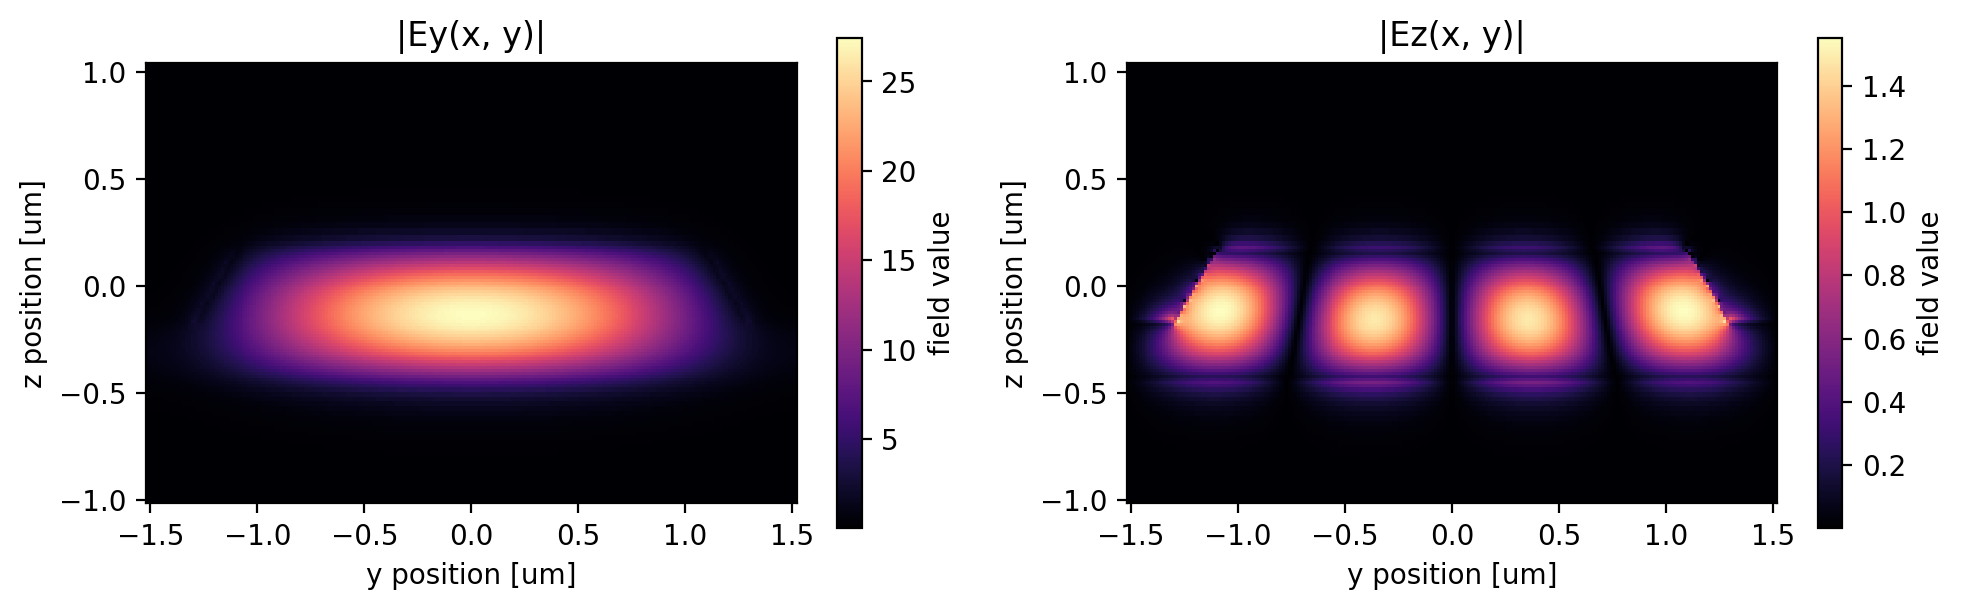

In [33]:

print(index )
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ey.isel(mode_index=index, f=f0_ind)).plot(x="y", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=index, f=f0_ind)).plot(x="y", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ey(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()




17:57:46 KST WARNING: Mode field at frequency index 2, mode index 4 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 3, mode index 4 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 4, mode index 4 does not    
             decay at the plane boundaries.                                     

17:57:54 KST WARNING: Mode '3' appears to undergo a discontinuous change between
             frequencies '413506838620689.7' and '399723277333333.3' (overlap:  
             '0.73').                                                           

             WARNING: Mode '4' appears to undergo a discontinuous change between
             frequencies '413506838620689.7' and '399723277333333.3' (overlap:  
             '0.73').                                                           

             WARNING: Mode '3' appears to undergo a discontinuous change between
             frequencies '428274940000000.0' and '413506838620689.7' (overlap:  
             '0.80').                                                           

             WARNING: Mode '4' appears to undergo a discontinuous change between
             frequencies '428274940000000.0' and '413506838620689.7' (overlap:  
             '0.80').                                                           

             WARNING: Mode '4' appears to undergo a discontinuous change between
             frequencies '374740572500000.0' and '386828978064516.1' (overlap:  
             '0.00').                                                           

/var/folders/9v/1g5tghgn28gf4q_nv_ycs20r0000gn/T/ipykernel_73933/381217207.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


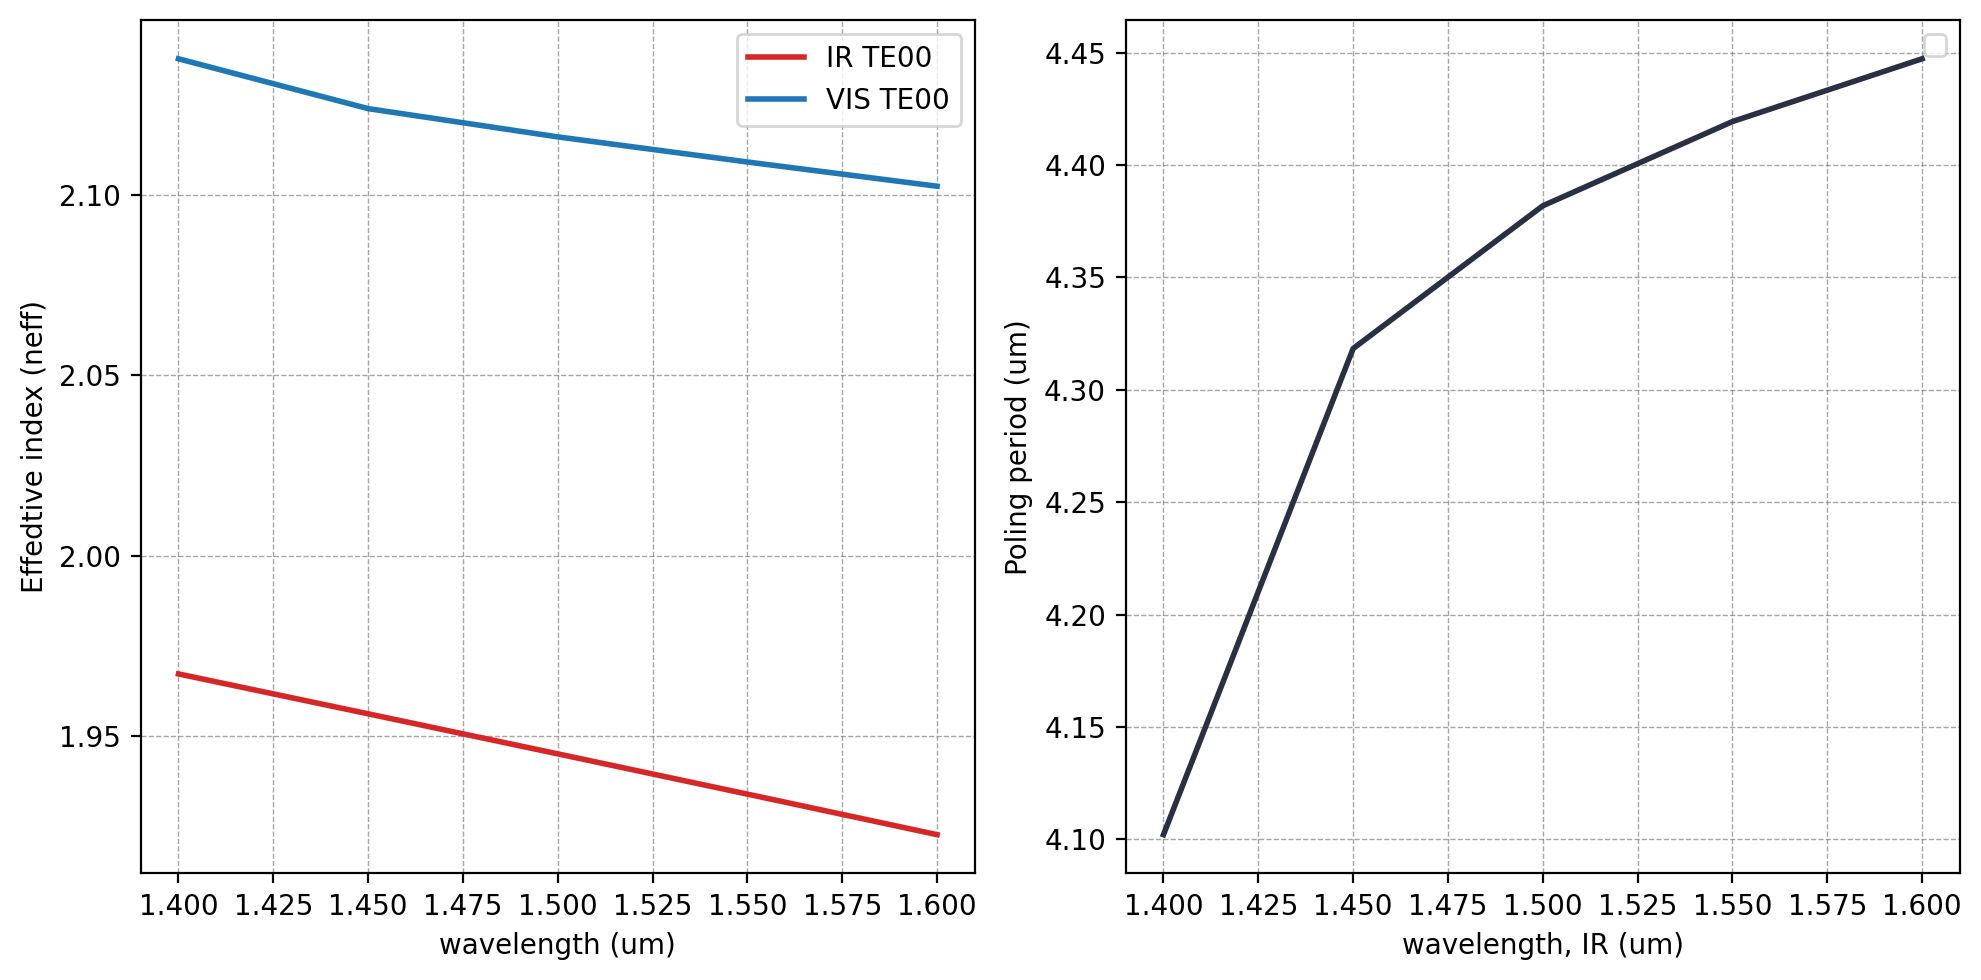

In [32]:
"""
freq0 = td.C_0 / 0.775
num_modes=2
source_plane2 = td.Box(center=[0, 0, 0], size=[0, 3, 2])
mode_spec = td.ModeSpec(num_modes=num_modes)
ms2 = ModeSolver(simulation=sim, plane=source_plane2, freqs=freq0, mode_spec=mode_spec)
modes_reso = ms2.solve()
f, axes = plt.subplots(num_modes, 3, tight_layout=True, figsize=(15, 12))
for axe, mode_index in zip(axes, range(num_modes)):
    for ax, field_name in zip(axe, ("Ex", "Ey", "Ez")):
        ms2.plot_field(field_name, "abs", f=freq0, mode_index=mode_index, ax=ax)
plt.show()
"""

wl_num=5
wl_range = np.linspace(1.4, 1.6, wl_num)
wl_range_vis = wl_range/2
freqs = td.C_0 / wl_range
freqs_vis = td.C_0 / wl_range_vis
# Modal source plane
source_plane1 = td.Box(center=[0, 0, 0], size=[0, 3, 2])



mode_spec = td.ModeSpec(
    num_modes=5,
    target_neff=2.2,
)
# NB: negative radius since the plane position is at y=-radius
ms1 = ModeSolver(simulation=sim, plane=source_plane1, freqs=freqs, mode_spec=mode_spec)
modes_IR = ms1.solve()
ms2 = ModeSolver(simulation=sim2, plane=source_plane1, freqs=freqs_vis, mode_spec=mode_spec)
modes_VIS = ms2.solve()


#mode_data = run_mode_solver(mode_solver)
# Plot the mode effective index.
n1 = modes_IR.n_eff.values.squeeze()[:,0]
n2 = modes_VIS.n_eff.values.squeeze()[:,index]
poling_period=wl_range / (2 * (n1 - n2))
fig, [ax,ax2] = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
y=[n1,n2]
x=wl_range
%config InlineBackend.figure_format = 'retina'
labels = ["IR TE00", "VIS TE00"]

colors =["#D62728","#1F77B4"]
for i, label in enumerate(labels):
    # Line
    ax.plot(x, y[i], label=label, color=colors[i], linewidth=2)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Effedtive index (neff)")
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

colors = ["#2B2F42", "#8D99AE", "#EF233C"]
ax2.plot(x,abs(poling_period), color=colors[0], linewidth=2)
ax2.set_xlabel("wavelength, IR (um)")
ax2.set_ylabel("Poling period (um)")
ax2.legend()
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.show()

